### Step 1 : Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

### Step 2 : Load the Dataset

In [ ]:
df = pd.read_csv("/content/Dataset .csv")

In [ ]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

### Step 3 : Data Preprocessing

1. Feature Selection - Select the Meaningful Features(Variables) which help to Predict the Restaurant Ratings

In [ ]:
df.drop(columns=["Restaurant ID", "Restaurant Name", "Address",
                 "Locality", "Locality Verbose","City","Rating color","Rating text"], inplace=True, errors='ignore')

In [ ]:
df

,Country Code,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,314
1,162,121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,591
2,162,121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,270
3,162,121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,365
4,162,121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,208,28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,788
9547,208,29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,1034
9548,208,29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,661
9549,208,29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,901


2. Handling the missing Values

In [ ]:
df.isnull().sum()

,0
Country Code,0
Longitude,0
Latitude,0
Cuisines,9
Average Cost for two,0
Currency,0
Has Table booking,0
Has Online delivery,0
Is delivering now,0
Switch to order menu,0


In [ ]:
# Fill numeric missing values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Country Code,0
Longitude,0
Latitude,0
Cuisines,0
Average Cost for two,0
Currency,0
Has Table booking,0
Has Online delivery,0
Is delivering now,0
Switch to order menu,0


### Step 4 : Categorical Value Encoding

In [ ]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df

,Country Code,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,121.027535,14.565443,920,1100,0,1,0,0,0,3,4.8,314
1,162,121.014101,14.553708,1111,1200,0,1,0,0,0,3,4.5,591
2,162,121.056831,14.581404,1671,4000,0,1,0,0,0,4,4.4,270
3,162,121.056475,14.585318,1126,1500,0,0,0,0,0,4,4.9,365
4,162,121.057508,14.584450,1122,1500,0,1,0,0,0,4,4.8,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,208,28.977392,41.022793,1813,80,11,0,0,0,0,3,4.1,788
9547,208,29.041297,41.009847,1824,105,11,0,0,0,0,3,4.2,1034
9548,208,29.034640,41.055817,1110,170,11,0,0,0,0,4,3.7,661
9549,208,29.036019,41.057979,1657,120,11,0,0,0,0,4,4.0,901


### Step 5 : Defining Non-Dependent(x) and Dependent(y) Variables

In [ ]:
X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

In [ ]:
X

,Country Code,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes
0,162,121.027535,14.565443,920,1100,0,1,0,0,0,3,314
1,162,121.014101,14.553708,1111,1200,0,1,0,0,0,3,591
2,162,121.056831,14.581404,1671,4000,0,1,0,0,0,4,270
3,162,121.056475,14.585318,1126,1500,0,0,0,0,0,4,365
4,162,121.057508,14.584450,1122,1500,0,1,0,0,0,4,229
...,...,...,...,...,...,...,...,...,...,...,...,...
9546,208,28.977392,41.022793,1813,80,11,0,0,0,0,3,788
9547,208,29.041297,41.009847,1824,105,11,0,0,0,0,3,1034
9548,208,29.034640,41.055817,1110,170,11,0,0,0,0,4,661
9549,208,29.036019,41.057979,1657,120,11,0,0,0,0,4,901


In [ ]:
y

,Aggregate rating
0,4.8
1,4.5
2,4.4
3,4.9
4,4.8
...,...
9546,4.1
9547,4.2
9548,3.7
9549,4.0


### Step 6 : Splitting the Dataset into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape

(7640, 12)

In [ ]:
X_test.shape

(1911, 12)

In [ ]:
X.shape

(9551, 12)

### Step 7 : Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[-0.30501664,  0.31932321,  0.23836107, ...,  0.        ,
         1.3159881 , -0.23251182],
       [-0.30501664,  0.31292726,  0.25182236, ...,  0.        ,
        -0.89298676, -0.35448121],
       [-0.30501664,  0.32126469,  0.24382698, ...,  0.        ,
        -0.89298676, -0.36386347],
       ...,
       [-0.30501664,  0.31663209,  0.24334015, ...,  0.        ,
        -0.89298676, -0.36386347],
       [-0.30501664,  0.33741291,  0.40788268, ...,  0.        ,
         2.42047553, -0.20905617],
       [-0.30501664,  0.31588245,  0.25952634, ...,  0.        ,
         0.21150067,  0.09352174]])

In [ ]:
X_test

array([[-0.30501664,  0.31506784,  0.25457927, ...,  0.        ,
        -0.89298676, -0.23720295],
       [-0.30501664,  0.31427703,  0.23723056, ...,  0.        ,
         0.21150067, -0.166836  ],
       [-0.30501664,  0.32014674,  0.24856732, ...,  0.        ,
         0.21150067, -0.27942313],
       ...,
       [-0.30501664,  0.32113597,  0.242631  , ...,  0.        ,
         0.21150067, -0.34040782],
       [-0.30501664,  0.32656053, -1.16710209, ...,  0.        ,
         1.3159881 ,  0.41955529],
       [ 3.48771868, -3.72545618,  1.43416209, ...,  0.        ,
         1.3159881 ,  0.64003842]])

### Step 8 : Regression Model Training

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Step 9 : Model Evaluationn

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)

In [ ]:
mse

0.08792760001177392

In [ ]:
r2 = r2_score(y_test, y_pred)

In [ ]:
r2

0.9613693367118512

### Step 10 : Feature Importance

In [ ]:
feature_importance = pd.Series(
model.feature_importances_, index=X.columns
).sort_values(ascending=False)

In [ ]:
feature_importance

,0
Votes,0.947632
Longitude,0.015741
Latitude,0.012373
Cuisines,0.010616
Average Cost for two,0.006781
Country Code,0.003330
Has Online delivery,0.001141
Price range,0.001006
Currency,0.000762
Has Table booking,0.000497


/tmp/ipython-input-3762541453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.index, y=feature_importance.values, palette='viridis')


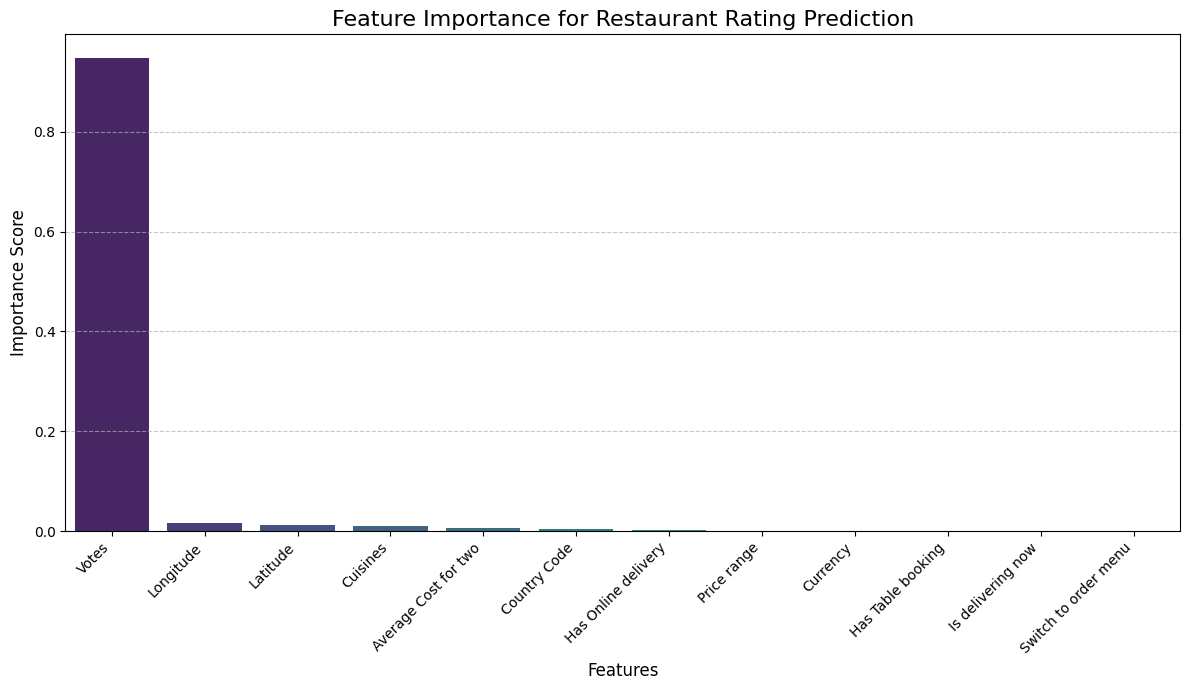

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance.index, y=feature_importance.values, palette='viridis')
plt.title('Feature Importance for Restaurant Rating Prediction', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 11 : Predicting the rating of the restaurant using the Input Features.

In [ ]:
df_raw = pd.read_csv("/content/Dataset .csv")

In [ ]:
sample = df_raw.sample(10, random_state=42)

restaurant_ids = sample["Restaurant ID"].values
actual_ratings = sample["Aggregate rating"].values

In [ ]:
sample_X = sample.drop(columns=[
    "Restaurant ID", "Restaurant Name", "Address",
                 "Locality", "Locality Verbose","City","Rating color","Rating text","Aggregate rating"
])

In [ ]:
# Encode categorical columns
for col in sample_X.select_dtypes(include="object").columns:
    sample_X[col] = le.fit_transform(sample_X[col])

# Scale
sample_X_scaled = scaler.transform(sample_X)

# Predict
predicted_ratings = model.predict(sample_X_scaled)

In [ ]:
results = pd.DataFrame({
    "Restaurant ID": restaurant_ids,
    "Actual Rating": actual_ratings,
    "Predicted Rating": predicted_ratings.round(2)
})

print(results)

   Restaurant ID  Actual Rating  Predicted Rating
0           3918            2.1              2.94
1       18408054            4.1              2.99
2         309693            3.2              2.79
3       18157386            4.4              3.54
4       18396163            3.5              3.30
5       18449643            0.0              0.00
6           2204            3.2              2.94
7         304771            0.0              0.00
8       18303845            3.6              2.68
9       18420454            4.0              3.11


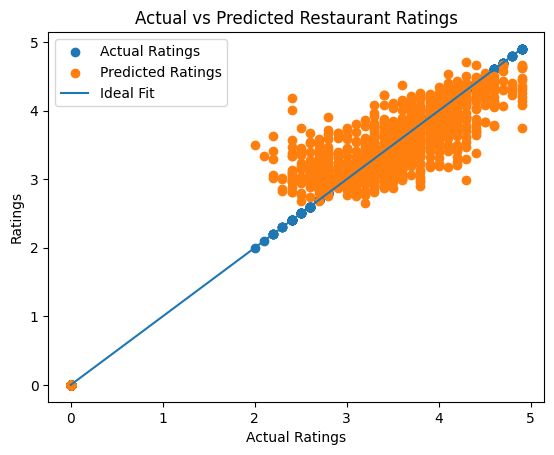

In [ ]:
# Convert to numpy arrays if needed
y_test_vals = np.array(y_test)
y_pred_vals = np.array(y_pred)

plt.figure()

# Scatter plot for actual ratings
plt.scatter(y_test_vals, y_test_vals, label="Actual Ratings")

# Scatter plot for predicted ratings
plt.scatter(y_test_vals, y_pred_vals, label="Predicted Ratings")

# Ideal regression line (perfect prediction)
min_val = min(y_test_vals)
max_val = max(y_test_vals)
plt.plot([min_val, max_val], [min_val, max_val], label="Ideal Fit")

plt.xlabel("Actual Ratings")
plt.ylabel("Ratings")
plt.title("Actual vs Predicted Restaurant Ratings")
plt.legend()
plt.show()
